# Redução ao 1º Quadrante

**Módulo:** 05 – Trigonometria (4º notebook do módulo)

**Pré-requisitos:** [`0501a_arcos_e_angulos.ipynb`](0501a_arcos_e_angulos.ipynb) (localização de arcos por quadrante, arcos côngruos), [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (sinal das funções circulares por quadrante) e [`0503a_relacoes_fundamentais.ipynb`](0503a_relacoes_fundamentais.ipynb) (relação fundamental, identidades)

**Objetivos de aprendizagem:**
- Reduzir o cálculo de qualquer função circular de um ângulo do 2º, 3º ou 4º quadrante ao valor equivalente no 1º quadrante.
- Usar a paridade (função par/ímpar) para reduzir arcos negativos e a congruência módulo 2π para reduzir arcos maiores que 360°.
- Aplicar a relação de co-função para reduzir ainda mais um ângulo do intervalo [45°, 90°] ao intervalo [0°, 45°].
- Construir, em Python, um algoritmo que calcula seno e cosseno de qualquer ângulo usando apenas valores conhecidos do primeiro quadrante.

**Tempo estimado:** 80 a 100 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0504a_reducao_ao_1o_quadrante.ipynb)

## A calculadora que não guardava uma tabela infinita

Como uma calculadora antiga, sem processador potente, calculava sen(200°) sem guardar uma tabela infinita de ângulos? A resposta é que ela não precisava: bastava conhecer os valores do primeiro quadrante (0° a 90°) e um conjunto de regras que "trazem de volta" qualquer ângulo para essa faixa conhecida.

Neste notebook você vai descobrir essas regras — e construir, aos poucos, sua própria versão dessa calculadora: uma função Python que calcula seno e cosseno de qualquer ângulo (positivo, negativo, maior que 360°) usando internamente só o que já se sabe sobre o 1º quadrante.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Panorama: Quatro Caminhos até o 1º Quadrante

Qualquer ângulo, por mais "esquisito" que pareça (grande, negativo, fora do 1º quadrante), tem um equivalente no intervalo [0°, 90°] cujo seno, cosseno e tangente já bastam para calcular os do ângulo original — a menos de um ajuste de sinal. Este notebook cobre quatro caminhos até esse equivalente:

- **por quadrante** — um ângulo do 2º, 3º ou 4º quadrante se reduz ao 1º quadrante por uma simetria do ciclo trigonométrico (Blocos 2, 3, 4);
- **por paridade** — um ângulo negativo se reduz ao seu correspondente positivo, porque cosseno é par e seno é ímpar (Blocos 5, 6);
- **por periodicidade** — um ângulo maior que 360° se reduz ao intervalo [0°, 360°) descontando voltas completas (Bloco 7);
- **por co-função** — um ângulo do 1º quadrante entre 45° e 90° ainda pode ser reduzido mais uma vez, ao intervalo [0°, 45°] (Bloco 8).

A base de tudo é a mesma de sempre: a simetria do ciclo trigonométrico construído em `0501a_arcos_e_angulos`, combinada com os sinais de cada função por quadrante, vistos em `0502a_funcoes_circulares`. Para recomeçar do mesmo ponto, a célula abaixo reconstrói as duas ferramentas que serão usadas o tempo todo neste notebook.

In [2]:
def quadrante(angulo_graus: float) -> str:
    '''Determina o quadrante de um ângulo qualquer, tratando ângulos negativos e maiores que 360°.'''
    angulo_normalizado = angulo_graus % 360

    if angulo_normalizado in (0, 90, 180, 270):
        return "sobre um eixo (não pertence a nenhum quadrante)"
    if angulo_normalizado < 90:
        return "1º quadrante"
    if angulo_normalizado < 180:
        return "2º quadrante"
    if angulo_normalizado < 270:
        return "3º quadrante"
    return "4º quadrante"


def sinal(valor: float) -> str:
    '''Classifica o sinal de um valor como positivo, negativo ou zero.'''
    if valor > 0:
        return "+"
    if valor < 0:
        return "-"
    return "0"


funcoes_circulares = {
    "sen": math.sin,
    "cos": math.cos,
    "tg": lambda x: math.sin(x) / math.cos(x),
    "cotg": lambda x: math.cos(x) / math.sin(x),
    "sec": lambda x: 1 / math.cos(x),
    "cossec": lambda x: 1 / math.sin(x),
}

quadrantes_referencia = {
    "I (0° a 90°)": math.radians(45),
    "II (90° a 180°)": math.radians(135),
    "III (180° a 270°)": math.radians(225),
    "IV (270° a 360°)": math.radians(315),
}

tabela_sinais = pd.DataFrame(
    {
        nome_q: [sinal(f(angulo)) for f in funcoes_circulares.values()]
        for nome_q, angulo in quadrantes_referencia.items()
    },
    index=list(funcoes_circulares.keys()),
)
tabela_sinais

,I (0° a 90°),II (90° a 180°),III (180° a 270°),IV (270° a 360°)
sen,+,+,-,-
cos,+,-,-,+
tg,+,-,+,-
cotg,+,-,+,-
sec,+,-,-,+
cossec,+,+,-,-


📎 **Conexão:** a função `quadrante` vem de `0501a_arcos_e_angulos` e a tabela de sinais vem de `0502a_funcoes_circulares` — as duas peças que este notebook vai combinar para construir as fórmulas de redução.

**Pergunta de checagem:** se soubermos sen(30°), o que mais precisamos saber para calcular sen(150°) sem uma calculadora?

## 2. Redução do 2º Quadrante ao 1º

Para um arco x no 2º quadrante, existe um arco x' = 180° − x (ou, em radianos, x' = π − x) no 1º quadrante tal que:

**sen(x) = sen(x')**
**cos(x) = −cos(x')**
**tg(x) = −tg(x')**

Essas fórmulas vêm da simetria do ciclo trigonométrico: o ponto do arco x é o reflexo, em torno do eixo vertical (eixo y), do ponto do arco x'. Uma reflexão em torno do eixo y preserva a altura do ponto (a ordenada, ou seja, o seno) e inverte sua posição horizontal (a abscissa, ou seja, o cosseno) — por isso sen não muda de sinal, e cos (e, por consequência, tg) muda.

In [3]:
def reduzir_2o_quadrante(angulo_graus: float) -> float:
    '''Reduz um ângulo do 2º quadrante ao ângulo equivalente no 1º quadrante.'''
    return 180 - angulo_graus


angulo_exemplo_2q = 150
angulo_reduzido_2q = reduzir_2o_quadrante(angulo_exemplo_2q)

tabela_reducao_2q = pd.DataFrame({
    "função": ["sen", "cos", "tg"],
    f"{angulo_exemplo_2q}° (2º quadrante)": [
        round(math.sin(math.radians(angulo_exemplo_2q)), 4),
        round(math.cos(math.radians(angulo_exemplo_2q)), 4),
        round(math.tan(math.radians(angulo_exemplo_2q)), 4),
    ],
    f"{angulo_reduzido_2q}° (1º quadrante)": [
        round(math.sin(math.radians(angulo_reduzido_2q)), 4),
        round(math.cos(math.radians(angulo_reduzido_2q)), 4),
        round(math.tan(math.radians(angulo_reduzido_2q)), 4),
    ],
})
tabela_reducao_2q

,função,150° (2º quadrante),30° (1º quadrante)
0,sen,0.5000,0.5000
1,cos,-0.8660,0.8660
2,tg,-0.5774,0.5774


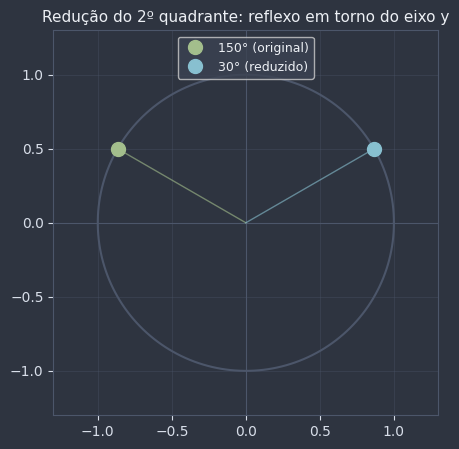

In [4]:
def plotar_reducao(angulo_graus: float, angulo_reduzido_graus: float, titulo: str) -> None:
    '''Desenha o ciclo trigonométrico com o ponto original e o ponto reduzido ao 1º quadrante.'''
    angulo_rad = math.radians(angulo_graus)
    angulo_reduzido_rad = math.radians(angulo_reduzido_graus)
    x_orig, y_orig = math.cos(angulo_rad), math.sin(angulo_rad)
    x_red, y_red = math.cos(angulo_reduzido_rad), math.sin(angulo_reduzido_rad)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_completos = np.linspace(0, 2 * math.pi, 200)
    ax.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

    ax.plot(x_orig, y_orig, "o", color=COR_DESTAQUE, markersize=10, label=f"{angulo_graus:.0f}° (original)")
    ax.plot(x_red, y_red, "o", color=COR_PONTO, markersize=10, label=f"{angulo_reduzido_graus:.0f}° (reduzido)")
    ax.plot([0, x_orig], [0, y_orig], color=COR_DESTAQUE, linewidth=1, alpha=0.6)
    ax.plot([0, x_red], [0, y_red], color=COR_PONTO, linewidth=1, alpha=0.6)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, loc="upper center", fontsize=9)
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=11)
    plt.show()


plotar_reducao(angulo_exemplo_2q, angulo_reduzido_2q, "Redução do 2º quadrante: reflexo em torno do eixo y")

🕹️ **Widget interativo:** mova o slider de ângulo entre 90° e 180° e observe o ponto original e o ponto espelhado no 1º quadrante, com os valores de seno e cosseno de ambos exibidos lado a lado.

In [5]:
def widget_reducao_2q(angulo_graus: float) -> None:
    angulo_reduzido = reduzir_2o_quadrante(angulo_graus)
    plotar_reducao(angulo_graus, angulo_reduzido, f"sen({angulo_graus:.0f}°) = sen({angulo_reduzido:.0f}°)   |   cos({angulo_graus:.0f}°) = −cos({angulo_reduzido:.0f}°)")

    tabela = pd.DataFrame({
        "função": ["sen", "cos"],
        f"{angulo_graus:.0f}°": [
            round(math.sin(math.radians(angulo_graus)), 4),
            round(math.cos(math.radians(angulo_graus)), 4),
        ],
        f"{angulo_reduzido:.0f}°": [
            round(math.sin(math.radians(angulo_reduzido)), 4),
            round(math.cos(math.radians(angulo_reduzido)), 4),
        ],
    })
    display(tabela)


widgets.interact(
    widget_reducao_2q,
    angulo_graus=widgets.IntSlider(min=90, max=180, step=1, value=150, description="ângulo (°)"),
)

interactive(children=(IntSlider(value=150, description='ângulo (°)', max=180, min=90), Output()), _dom_classes…

<function __main__.widget_reducao_2q(angulo_graus: float) -> None>

📌 **Fórmulas de redução do 2º quadrante:** sen(x) = sen(180° − x); cos(x) = −cos(180° − x); tg(x) = −tg(180° − x).

**Pergunta de checagem:** por que cos(150°) é negativo, mesmo sabendo que cos(30°) é positivo?

## 3. Redução do 3º Quadrante ao 1º

Para um arco x no 3º quadrante, x' = x − 180° (x − π rad) está no 1º quadrante, com:

**sen(x) = −sen(x')**
**cos(x) = −cos(x')**
**tg(x) = tg(x')**

Geometricamente, o ponto do arco x é o reflexo do ponto do arco x' em relação à origem (uma rotação de 180°) — por isso seno e cosseno trocam de sinal juntos, mas a razão entre eles (a tangente) permanece igual.

In [6]:
def reduzir_3o_quadrante(angulo_graus: float) -> float:
    '''Reduz um ângulo do 3º quadrante ao ângulo equivalente no 1º quadrante.'''
    return angulo_graus - 180


angulo_exemplo_3q = 210
angulo_reduzido_3q = reduzir_3o_quadrante(angulo_exemplo_3q)

tabela_reducao_3q = pd.DataFrame({
    "função": ["sen", "cos", "tg"],
    f"{angulo_exemplo_3q}° (3º quadrante)": [
        round(math.sin(math.radians(angulo_exemplo_3q)), 4),
        round(math.cos(math.radians(angulo_exemplo_3q)), 4),
        round(math.tan(math.radians(angulo_exemplo_3q)), 4),
    ],
    f"{angulo_reduzido_3q}° (1º quadrante)": [
        round(math.sin(math.radians(angulo_reduzido_3q)), 4),
        round(math.cos(math.radians(angulo_reduzido_3q)), 4),
        round(math.tan(math.radians(angulo_reduzido_3q)), 4),
    ],
})
tabela_reducao_3q

,função,210° (3º quadrante),30° (1º quadrante)
0,sen,-0.5000,0.5000
1,cos,-0.8660,0.8660
2,tg,0.5774,0.5774


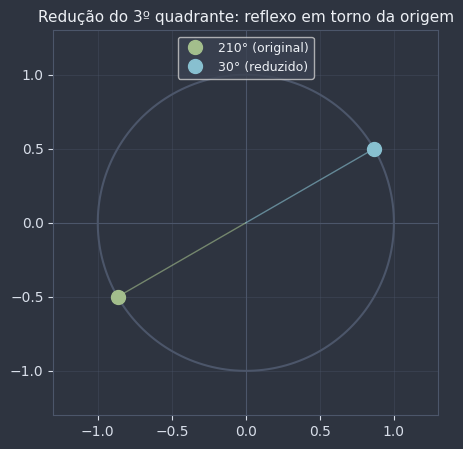

In [7]:
plotar_reducao(angulo_exemplo_3q, angulo_reduzido_3q, "Redução do 3º quadrante: reflexo em torno da origem")

💡 **Dica mnemônica:** no 3º quadrante, apenas a tangente (e a cotangente) preservam o sinal, porque seno e cosseno "trocam de sinal juntos" — o mesmo sinal negativo aparece nos dois, e a divisão de dois negativos dá positivo.

**Pergunta de checagem:** por que tg(210°) tem o mesmo sinal que tg(30°), mas sen(210°) não tem o mesmo sinal que sen(30°)?

## 4. Redução do 4º Quadrante ao 1º

Para um arco x no 4º quadrante, x' = 360° − x (2π − x) está no 1º quadrante, com:

**sen(x) = −sen(x')**
**cos(x) = cos(x')**
**tg(x) = −tg(x')**

Aqui o ponto do arco x é o reflexo do ponto do arco x' em torno do eixo horizontal (eixo x): a posição horizontal (o cosseno) se preserva, e a altura (o seno) inverte de sinal.

🎯 **Aplicação prática — construindo a "calculadora universal" (parte 1):** com as três reduções vistas até aqui (Blocos 2, 3 e 4), já é possível escrever uma função que calcula o seno de qualquer ângulo entre 0° e 360° usando internamente apenas `math.sin` restrito a ângulos entre 0° e 90° — como se fosse uma "tábua" que só conhece o 1º quadrante.

In [8]:
def seno_reduzido(angulo_graus: float) -> float:
    '''Calcula sen(angulo_graus), para 0 <= angulo_graus < 360, usando math.sin
    restrito a ângulos entre 0° e 90°.'''
    if angulo_graus in (0, 180):
        return 0.0
    if angulo_graus == 90:
        return 1.0
    if angulo_graus == 270:
        return -1.0

    q = quadrante(angulo_graus)
    if q == "1º quadrante":
        angulo_1q, sinal_final = angulo_graus, 1
    elif q == "2º quadrante":
        angulo_1q, sinal_final = reduzir_2o_quadrante(angulo_graus), 1
    elif q == "3º quadrante":
        angulo_1q, sinal_final = reduzir_3o_quadrante(angulo_graus), -1
    else:  # 4º quadrante
        angulo_1q, sinal_final = 360 - angulo_graus, -1

    return sinal_final * math.sin(math.radians(angulo_1q))


angulos_teste_seno_reduzido = [10, 80, 150, 200, 260, 310, 0, 90, 180, 270]
for a in angulos_teste_seno_reduzido:
    valor_reduzido = seno_reduzido(a)
    valor_direto = math.sin(math.radians(a))
    assert abs(valor_reduzido - valor_direto) < 1e-9, f"falhou para {a}°"
    print(f"seno_reduzido({a:>3}°) = {valor_reduzido: .4f}   |   math.sin = {valor_direto: .4f}")

print("\nseno_reduzido bate com math.sin para todos os ângulos testados.")

seno_reduzido( 10°) =  0.1736   |   math.sin =  0.1736
seno_reduzido( 80°) =  0.9848   |   math.sin =  0.9848
seno_reduzido(150°) =  0.5000   |   math.sin =  0.5000
seno_reduzido(200°) = -0.3420   |   math.sin = -0.3420
seno_reduzido(260°) = -0.9848   |   math.sin = -0.9848
seno_reduzido(310°) = -0.7660   |   math.sin = -0.7660
seno_reduzido(  0°) =  0.0000   |   math.sin =  0.0000
seno_reduzido( 90°) =  1.0000   |   math.sin =  1.0000
seno_reduzido(180°) =  0.0000   |   math.sin =  0.0000
seno_reduzido(270°) = -1.0000   |   math.sin = -1.0000

seno_reduzido bate com math.sin para todos os ângulos testados.


⚠️ **Erro comum:** no 4º quadrante é o **cosseno** que preserva o sinal, e não o seno (o inverso do que acontece no 2º quadrante) — é fácil trocar um pelo outro na hora de decorar as fórmulas. A tabela do Bloco 9 reúne os quatro casos lado a lado para facilitar a comparação.

**Pergunta de checagem:** qual das três funções (seno, cosseno, tangente) muda de sinal ao reduzir um ângulo do 4º quadrante para o 1º?

## 5. Funções Pares e Ímpares

Uma função f é **par** quando f(−x) = f(x) para todo x do domínio — seu gráfico é simétrico em relação ao eixo y. Uma função f é **ímpar** quando f(−x) = −f(x) — seu gráfico é simétrico em relação à origem.

📌 **Definição formal:** f é par ⟺ f(−x) = f(x), para todo x no domínio de f. f é ímpar ⟺ f(−x) = −f(x), para todo x no domínio de f.

No ciclo trigonométrico, o arco −x é o reflexo do arco x em relação ao eixo horizontal (eixo x): a posição horizontal (cosseno) se preserva, e a altura (seno) inverte de sinal. Essa é exatamente a simetria de uma função par para o cosseno e de uma função ímpar para o seno:

**cos(−x) = cos(x)** → cosseno é uma função **par**

**sen(−x) = −sen(x)** → seno é uma função **ímpar**

In [9]:
angulos_teste_paridade = [15, 47, 93, 158, 210, 289]

for a in angulos_teste_paridade:
    x = math.radians(a)
    assert abs(math.cos(-x) - math.cos(x)) < 1e-9, f"cos não é par para x={a}°"
    assert abs(math.sin(-x) - (-math.sin(x))) < 1e-9, f"sen não é ímpar para x={a}°"

print("cos(-x) == cos(x) e sen(-x) == -sen(x) para todos os ângulos testados.")

cos(-x) == cos(x) e sen(-x) == -sen(x) para todos os ângulos testados.


📖 **Leitura complementar:** [Paridade de funções — Wikipédia](https://pt.wikipedia.org/wiki/Paridade_de_fun%C3%A7%C3%B5es)

**Pergunta de checagem:** sabendo que cosseno é par e seno é ímpar, o que se pode concluir sobre a paridade da tangente, que é a razão entre os dois?

## 6. Redução de Arcos Negativos

A paridade do bloco anterior já é, na prática, uma regra de redução: para calcular a função circular de um arco negativo, basta calcular a função do arco positivo correspondente e ajustar o sinal quando necessário.

**sen(−x) = −sen(x)**
**cos(−x) = cos(x)**
**tg(−x) = −tg(x)**

(a última fórmula segue das duas primeiras: tg(−x) = sen(−x)/cos(−x) = −sen(x)/cos(x) = −tg(x))

In [10]:
angulo_negativo_exemplo = -40
angulo_positivo_correspondente = -angulo_negativo_exemplo

sen_positivo = math.sin(math.radians(angulo_positivo_correspondente))
cos_positivo = math.cos(math.radians(angulo_positivo_correspondente))
tg_positivo = math.tan(math.radians(angulo_positivo_correspondente))

sen_via_paridade = -sen_positivo
cos_via_paridade = cos_positivo
tg_via_paridade = -tg_positivo

tabela_paridade = pd.DataFrame({
    "função": ["sen", "cos", "tg"],
    f"{angulo_negativo_exemplo}° (via paridade)": [
        round(sen_via_paridade, 4), round(cos_via_paridade, 4), round(tg_via_paridade, 4),
    ],
    f"{angulo_negativo_exemplo}° (direto, math)": [
        round(math.sin(math.radians(angulo_negativo_exemplo)), 4),
        round(math.cos(math.radians(angulo_negativo_exemplo)), 4),
        round(math.tan(math.radians(angulo_negativo_exemplo)), 4),
    ],
})
tabela_paridade

,função,-40° (via paridade),"-40° (direto, math)"
0,sen,-0.6428,-0.6428
1,cos,0.7660,0.7660
2,tg,-0.8391,-0.8391


💡 **Dica:** arcos negativos "andam" no sentido horário no ciclo trigonométrico; pensar neles como o espelho do arco positivo em relação ao eixo horizontal ajuda a lembrar os sinais sem decorar as três fórmulas separadamente.

**Pergunta de checagem:** sen(−90°) é igual a sen(90°), a −sen(90°), ou a nenhum dos dois?

## 7. Redução de Arcos Maiores que 360° (Congruência Módulo 2π)

Em `0501a_arcos_e_angulos`, arcos côngruos (ou coterminais) foram definidos como arcos que terminam no mesmo ponto do ciclo trigonométrico: α + k·360°, para qualquer inteiro k. Como as funções circulares dependem só da posição do ponto no ciclo, isso significa que elas são **periódicas**:

**sen(x + 2πk) = sen(x)**, para qualquer inteiro k (e o mesmo vale para cos e tg, com período π para a tangente)

Ou seja: "descontar" voltas completas de um ângulo não muda o valor de nenhuma função circular — é sempre possível trazer um ângulo qualquer para dentro do intervalo [0°, 360°) antes de aplicar as reduções por quadrante dos Blocos 2 a 4.

🎯 **Aplicação prática — completando a "calculadora universal" (parte 2):** o operador `%` (módulo) resolve exatamente esse passo, para ângulos negativos ou maiores que 360°. Combinando isso com `seno_reduzido` do Bloco 4, `seno_universal` já calcula o seno de **qualquer** ângulo.

In [11]:
def seno_universal(angulo_graus: float) -> float:
    '''Calcula sen(angulo_graus) para qualquer ângulo — positivo, negativo ou maior que 360°.'''
    angulo_no_ciclo = angulo_graus % 360
    return seno_reduzido(angulo_no_ciclo)


angulos_teste_universal = [-750, -30, 400, 750, 1080, -1000]
for a in angulos_teste_universal:
    valor_universal = seno_universal(a)
    valor_direto = math.sin(math.radians(a))
    assert abs(valor_universal - valor_direto) < 1e-9, f"falhou para {a}°"
    print(f"seno_universal({a:>5}°) = {valor_universal: .4f}   |   math.sin = {valor_direto: .4f}")

print("\nseno_universal bate com math.sin para todos os ângulos testados, mesmo fora de [0°, 360°).")

seno_universal( -750°) = -0.5000   |   math.sin = -0.5000
seno_universal(  -30°) = -0.5000   |   math.sin = -0.5000
seno_universal(  400°) =  0.6428   |   math.sin =  0.6428
seno_universal(  750°) =  0.5000   |   math.sin =  0.5000
seno_universal( 1080°) =  0.0000   |   math.sin = -0.0000
seno_universal(-1000°) =  0.9848   |   math.sin =  0.9848

seno_universal bate com math.sin para todos os ângulos testados, mesmo fora de [0°, 360°).


🕹️ **Widget interativo:** ajuste o número de voltas k somado a um ângulo base e observe que o ponto no ciclo trigonométrico — e os valores de seno e cosseno — não mudam, não importa quantas voltas completas sejam somadas.

In [12]:
angulo_base_congruencia = 50

def widget_congruencia(k: int) -> None:
    angulo_com_voltas = angulo_base_congruencia + k * 360
    angulo_no_ciclo = angulo_com_voltas % 360
    angulo_rad = math.radians(angulo_no_ciclo)
    x_p, y_p = math.cos(angulo_rad), math.sin(angulo_rad)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_completos = np.linspace(0, 2 * math.pi, 200)
    ax.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.plot(x_p, y_p, "o", color=COR_DESTAQUE, markersize=12)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.set_title(
        f"{angulo_base_graus_texto} + {k}·360° = {angulo_com_voltas}°   (mesmo ponto: {angulo_no_ciclo}°)",
        color=NORD_TEXTO, fontsize=10,
    )
    plt.show()

    print(f"sen({angulo_com_voltas}°) = {math.sin(angulo_rad): .4f}   |   cos({angulo_com_voltas}°) = {math.cos(angulo_rad): .4f}")


angulo_base_graus_texto = f"{angulo_base_congruencia}°"
widgets.interact(
    widget_congruencia,
    k=widgets.IntSlider(min=-3, max=3, step=1, value=0, description="k (voltas)"),
)

interactive(children=(IntSlider(value=0, description='k (voltas)', max=3, min=-3), Output()), _dom_classes=('w…

<function __main__.widget_congruencia(k: int) -> None>

📎 **Conexão:** os arcos côngruos foram apresentados em `0501a_arcos_e_angulos`, Bloco 9 — aqui a mesma ideia é reaproveitada para reduzir qualquer ângulo, por maior que seja, de volta ao intervalo [0°, 360°).

📖 **Leitura complementar:** [Aritmética modular — Wikipédia](https://pt.wikipedia.org/wiki/Aritm%C3%A9tica_modular)

**Pergunta de checagem:** qual o valor equivalente de 750° dentro do intervalo [0°, 360°)?

## 8. Redução de [45°, 90°] a [0°, 45°]

Existe ainda uma última redução possível, interna ao próprio 1º quadrante: a relação de co-função entre ângulos complementares (que somam 90°):

**sen(90° − x) = cos(x)**
**cos(90° − x) = sen(x)**

Se x estiver entre 45° e 90°, então 90° − x estará entre 0° e 45° — ou seja, qualquer ângulo do 1º quadrante acima de 45° pode ser reescrito em termos de um ângulo abaixo de 45°, trocando seno por cosseno (ou vice-versa).

In [13]:
def reduzir_por_cofuncao(angulo_graus: float) -> tuple[float, str]:
    '''Reduz um ângulo entre 45° e 90° ao intervalo [0°, 45°] usando a relação de co-função.'''
    angulo_reduzido = 90 - angulo_graus
    formula = (
        f"sen({angulo_graus}°) = cos({angulo_reduzido}°)   e   "
        f"cos({angulo_graus}°) = sen({angulo_reduzido}°)"
    )
    return angulo_reduzido, formula


angulo_exemplo_cofuncao = 70
angulo_reduzido_cofuncao, formula_cofuncao = reduzir_por_cofuncao(angulo_exemplo_cofuncao)
print(formula_cofuncao)

sen_via_cofuncao = math.cos(math.radians(angulo_reduzido_cofuncao))
sen_direto = math.sin(math.radians(angulo_exemplo_cofuncao))
print(f"\nsen({angulo_exemplo_cofuncao}°) via co-função: {sen_via_cofuncao:.4f}   |   direto (math.sin): {sen_direto:.4f}")

sen(70°) = cos(20°)   e   cos(70°) = sen(20°)

sen(70°) via co-função: 0.9397   |   direto (math.sin): 0.9397


🕵️ **Curiosidade histórica:** é por isso que as tábuas trigonométricas antigas, anteriores às calculadoras, costumavam listar valores só até 45°: qualquer ângulo acima disso podia ser obtido pela relação de co-função, economizando metade das linhas da tabela.

📖 **Leitura complementar:** [História da trigonometria — Wikipédia](https://pt.wikipedia.org/wiki/Hist%C3%B3ria_da_trigonometria)

**Pergunta de checagem:** por que a palavra "cosseno" começa com "co-", assim como "cotangente" e "cossecante"?

## 9. Tabela-Resumo de Sinais e Reduções por Quadrante

| Quadrante | x' (ângulo reduzido) | sen(x) | cos(x) | tg(x) |
|---|---|---|---|---|
| 2º (90° a 180°) | 180° − x | sen(x') | −cos(x') | −tg(x') |
| 3º (180° a 270°) | x − 180° | −sen(x') | −cos(x') | tg(x') |
| 4º (270° a 360°) | 360° − x | −sen(x') | cos(x') | −tg(x') |

🎯 **Aplicação prática — a "calculadora universal", versão final:** juntando a redução por periodicidade (Bloco 7) com a redução por quadrante (Blocos 2 a 4), `calculadora_universal` calcula sen, cos e tg de **qualquer** ângulo real usando internamente só valores do 1º quadrante.

In [14]:
def calculadora_universal(angulo_graus: float) -> dict[str, float]:
    '''Calcula sen, cos e tg de qualquer ângulo, reduzindo-o ao 1º quadrante.'''
    angulo_no_ciclo = angulo_graus % 360

    if angulo_no_ciclo in (0, 180):
        sen_x, cos_x = (0.0, 1.0) if angulo_no_ciclo == 0 else (0.0, -1.0)
    elif angulo_no_ciclo == 90:
        sen_x, cos_x = 1.0, 0.0
    elif angulo_no_ciclo == 270:
        sen_x, cos_x = -1.0, 0.0
    else:
        q = quadrante(angulo_no_ciclo)
        if q == "1º quadrante":
            angulo_1q, sinal_sen, sinal_cos = angulo_no_ciclo, 1, 1
        elif q == "2º quadrante":
            angulo_1q, sinal_sen, sinal_cos = reduzir_2o_quadrante(angulo_no_ciclo), 1, -1
        elif q == "3º quadrante":
            angulo_1q, sinal_sen, sinal_cos = reduzir_3o_quadrante(angulo_no_ciclo), -1, -1
        else:  # 4º quadrante
            angulo_1q, sinal_sen, sinal_cos = 360 - angulo_no_ciclo, -1, 1

        angulo_1q_rad = math.radians(angulo_1q)
        sen_x = sinal_sen * math.sin(angulo_1q_rad)
        cos_x = sinal_cos * math.cos(angulo_1q_rad)

    tg_x = sen_x / cos_x if abs(cos_x) > 1e-12 else math.nan
    return {"sen": sen_x, "cos": cos_x, "tg": tg_x}


angulos_teste_final = [30, 130, 200, 310, -430, 820, -30, 0, 90, 180, 270, 1000]
for a in angulos_teste_final:
    resultado = calculadora_universal(a)
    esperado = {"sen": math.sin(math.radians(a)), "cos": math.cos(math.radians(a))}
    assert abs(resultado["sen"] - esperado["sen"]) < 1e-9, f"sen falhou para {a}°"
    assert abs(resultado["cos"] - esperado["cos"]) < 1e-9, f"cos falhou para {a}°"

print("calculadora_universal bate com math.sin e math.cos para todos os ângulos testados.")

calculadora_universal bate com math.sin e math.cos para todos os ângulos testados.


🕹️ **Widget interativo:** digite qualquer ângulo (positivo, negativo, maior que 360°) e veja, passo a passo, o processo completo — redução módulo 360° → identificação do quadrante → aplicação da fórmula → valor final — comparado com o resultado de `math.sin` para conferência.

In [15]:
def widget_calculadora_universal(angulo_graus: float) -> None:
    angulo_no_ciclo = angulo_graus % 360
    q = quadrante(angulo_no_ciclo)
    resultado = calculadora_universal(angulo_graus)
    valor_math = math.sin(math.radians(angulo_graus))

    print(f"1. ângulo original:            {angulo_graus}°")
    print(f"2. reduzido a [0°, 360°):      {angulo_graus}° % 360° = {angulo_no_ciclo}°")
    print(f"3. quadrante:                  {q}")
    print(f"4. sen calculado (reduções):   {resultado['sen']:.6f}")
    print(f"5. sen direto (math.sin):      {valor_math:.6f}")
    print(f"\ndiferença: {abs(resultado['sen'] - valor_math):.2e}")


widgets.interact(
    widget_calculadora_universal,
    angulo_graus=widgets.FloatText(value=-430, description="ângulo (°)"),
)

interactive(children=(FloatText(value=-430.0, description='ângulo (°)'), Output()), _dom_classes=('widget-inte…

<function __main__.widget_calculadora_universal(angulo_graus: float) -> None>

📌 A tabela deste bloco reúne, lado a lado, as três fórmulas de redução por quadrante — a comparação entre as linhas é a melhor forma de fixar onde cada sinal muda (e onde não muda).

**Pergunta de checagem:** sem calcular diretamente, qual seria o primeiro passo para calcular sen(−430°) usando tudo o que foi visto neste notebook?

## Resumo — cheat sheet

| Redução | Fórmulas |
|---|---|
| 2º quadrante → 1º (x' = 180° − x) | sen(x) = sen(x'); cos(x) = −cos(x'); tg(x) = −tg(x') |
| 3º quadrante → 1º (x' = x − 180°) | sen(x) = −sen(x'); cos(x) = −cos(x'); tg(x) = tg(x') |
| 4º quadrante → 1º (x' = 360° − x) | sen(x) = −sen(x'); cos(x) = cos(x'); tg(x) = −tg(x') |
| Paridade (arcos negativos) | sen(−x) = −sen(x); cos(−x) = cos(x); tg(−x) = −tg(x) |
| Periodicidade (arcos > 360°) | sen(x + 2πk) = sen(x), para qualquer inteiro k |
| Co-função ([45°,90°] → [0°,45°]) | sen(90° − x) = cos(x); cos(90° − x) = sen(x) |

| Quadrante | sen | cos | tg | cotg | sec | cossec |
|---|---|---|---|---|---|---|
| I | + | + | + | + | + | + |
| II | + | − | − | − | − | + |
| III | − | − | + | + | − | − |
| IV | − | + | − | − | + | − |

## Exercícios

**Básico**
1. Reduzir ângulos dados de cada quadrante (2º, 3º, 4º) ao 1º quadrante e calcular o valor da função circular pedida.
2. Usar a paridade para calcular o valor de funções circulares de um arco negativo.

**Intermediário**
3. Reduzir um ângulo maior que 360° ao intervalo [0°, 360°) antes de aplicar a redução por quadrante.
4. Usar a relação de co-função para reduzir um ângulo entre 45° e 90° ao intervalo entre 0° e 45°.

**Desafio**
5. Implementar, sem consultar o notebook, a lógica de redução ao 1º quadrante para calcular seno, cosseno e tangente de vários ângulos.
6. Resolver um problema que combine várias reduções em sequência: calcular sen(−750°) do início ao fim, mostrando cada passo.

### Básico

In [ ]:
# Exercício Básico 1: os ângulos abaixo pertencem, nessa ordem, ao 2º, 3º e 4º
# quadrante. Reduza cada um ao 1º quadrante e calcule o valor pedido (sem usar
# a função direta do math no ângulo original -- calcule a partir do ângulo
# reduzido). Guarde as respostas como uma lista de floats, arredondados a 4
# casas decimais, na ordem: [sen(160°), cos(200°), sen(300°)].
resultados_exercicio1 = ...  # ex: [valor1, valor2, valor3]

print(resultados_exercicio1)

In [ ]:
# Verificação
esperado_exercicio1 = [
    round(math.sin(math.radians(160)), 4),
    round(math.cos(math.radians(200)), 4),
    round(math.sin(math.radians(300)), 4),
]
assert resultados_exercicio1 == esperado_exercicio1, (
    "Tente de novo, revise: reduza 160° ao 2º quadrante (x'=180°-x), 200° ao 3º "
    "quadrante (x'=x-180°) e 300° ao 4º quadrante (x'=360°-x), depois aplique o "
    "sinal correto (seções 2, 3 e 4 - Redução por Quadrante)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: sabendo que sen(35°) = 0.5736 e cos(35°) = 0.8192 (já
# arredondados a 4 casas decimais), use a paridade para calcular sen(-35°) e
# cos(-35°) sem nenhum novo cálculo trigonométrico. Guarde a resposta como uma
# tupla (sen_menos_35, cos_menos_35).
sen_35 = 0.5736
cos_35 = 0.8192
respostas_exercicio2 = ...  # ex: (sen_menos_35, cos_menos_35)

print(respostas_exercicio2)

In [ ]:
# Verificação
esperado_exercicio2 = (-sen_35, cos_35)
assert respostas_exercicio2 == esperado_exercicio2, (
    "Tente de novo, revise: sen(-x) = -sen(x) e cos(-x) = cos(x) (seção 5 e 6 - "
    "Funções Pares e Ímpares / Redução de Arcos Negativos)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: reduza 830° ao intervalo [0°, 360°) e calcule
# sen(830°). Guarde o ângulo já reduzido a [0°, 360°) em
# angulo_reduzido_exercicio3 (int) e o valor de sen(830°) em sen_exercicio3
# (float, arredondado a 4 casas decimais).
angulo_reduzido_exercicio3 = ...
sen_exercicio3 = ...

print(angulo_reduzido_exercicio3, sen_exercicio3)

In [ ]:
# Verificação
esperado_angulo_exercicio3 = 830 % 360
esperado_sen_exercicio3 = round(math.sin(math.radians(830)), 4)
assert angulo_reduzido_exercicio3 == esperado_angulo_exercicio3, (
    "Tente de novo, revise: use o operador % para trazer 830° ao intervalo "
    "[0°, 360°) (seção 7 - Redução por Periodicidade)."
)
assert sen_exercicio3 == esperado_sen_exercicio3, (
    "Tente de novo, revise: depois de reduzir o ângulo a [0°, 360°), aplique a "
    "redução por quadrante correspondente (seção 7 - Redução por Periodicidade)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: use a relação de co-função para reduzir 80° ao
# intervalo [0°, 45°], e calcule cos(80°) a partir do seno do ângulo reduzido
# (não use math.cos(80°) diretamente). Guarde o ângulo reduzido em
# angulo_reduzido_exercicio4 (int) e o valor calculado em cos_exercicio4
# (float, arredondado a 4 casas decimais).
angulo_reduzido_exercicio4 = ...
cos_exercicio4 = ...

print(angulo_reduzido_exercicio4, cos_exercicio4)

In [ ]:
# Verificação
esperado_angulo_exercicio4 = 90 - 80
esperado_cos_exercicio4 = round(math.sin(math.radians(esperado_angulo_exercicio4)), 4)
assert angulo_reduzido_exercicio4 == esperado_angulo_exercicio4, (
    "Tente de novo, revise: o ângulo reduzido pela co-função é 90° - 80° "
    "(seção 8 - Redução por Co-função)."
)
assert cos_exercicio4 == esperado_cos_exercicio4, (
    "Tente de novo, revise: cos(80°) = sen(90° - 80°) = sen(10°) "
    "(seção 8 - Redução por Co-função)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: sem consultar o notebook, implemente a lógica que reduz
# cada um dos ângulos abaixo ao 1º quadrante para calcular sen, cos e tg, e
# compare com os valores diretos de math.sin/cos/tan (tolerância 1e-9). Guarde
# o resultado como uma lista de booleanos (True se as três funções baterem com
# o math dentro da tolerância), na mesma ordem dos ângulos.
angulos_teste_exercicio5 = [130, 250, 310, -60, 800]
resultados_exercicio5 = ...  # ex: [True, True, ...]

print(resultados_exercicio5)

In [ ]:
# Verificação
tolerancia_exercicio5 = 1e-9
esperado_exercicio5 = []
for a in angulos_teste_exercicio5:
    resultado_confiavel = calculadora_universal(a)
    bate = (
        abs(resultado_confiavel["sen"] - math.sin(math.radians(a))) < tolerancia_exercicio5
        and abs(resultado_confiavel["cos"] - math.cos(math.radians(a))) < tolerancia_exercicio5
        and abs(resultado_confiavel["tg"] - math.tan(math.radians(a))) < tolerancia_exercicio5
    )
    esperado_exercicio5.append(bate)

assert len(resultados_exercicio5) == len(angulos_teste_exercicio5), (
    "Tente de novo, revise: a lista de resultados deve ter um booleano para cada "
    "ângulo testado (seção 9 - Tabela-Resumo de Sinais e Reduções por Quadrante)."
)
assert resultados_exercicio5 == esperado_exercicio5, (
    "Tente de novo, revise: implemente sen, cos e tg a partir da redução ao 1º "
    "quadrante (Blocos 2 a 4 e 7) e compare com math.sin/cos/tan; todos os "
    "ângulos testados devem bater dentro da tolerância "
    "(seção 9 - Tabela-Resumo de Sinais e Reduções por Quadrante)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: calcule sen(-750°) do início ao fim, mostrando cada
# passo: (a) reduza -750° ao intervalo [0°, 360°); (b) identifique o quadrante
# desse ângulo reduzido (use a função quadrante); (c) calcule sen(-750°).
# Guarde o resultado como uma tupla (angulo_no_intervalo, quadrante_do_angulo,
# sen_final), onde angulo_no_intervalo é int, quadrante_do_angulo é a string
# devolvida por quadrante(...), e sen_final é float arredondado a 4 casas
# decimais.
respostas_exercicio6 = ...  # ex: (angulo_no_intervalo, quadrante_do_angulo, sen_final)

print(respostas_exercicio6)

In [ ]:
# Verificação
esperado_exercicio6 = (
    -750 % 360,
    quadrante(-750 % 360),
    round(math.sin(math.radians(-750)), 4),
)
assert respostas_exercicio6 == esperado_exercicio6, (
    "Tente de novo, revise: primeiro reduza -750° com % 360 (seção 7), depois "
    "identifique o quadrante do ângulo resultante e aplique a fórmula de redução "
    "correspondente (seções 2 a 4 - Redução por Quadrante)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Redução ao 1º quadrante | expressar sen, cos ou tg de qualquer ângulo em termos do valor equivalente entre 0° e 90° |
| Função par | f(−x) = f(x) para todo x do domínio; cosseno é par |
| Função ímpar | f(−x) = −f(x) para todo x do domínio; seno é ímpar |
| Congruência módulo 2π | sen(x + 2πk) = sen(x) para qualquer inteiro k; base da redução por periodicidade |
| Relação de co-função | sen(90° − x) = cos(x) e cos(90° − x) = sen(x), para ângulos complementares |
| Calculadora universal | função construída neste notebook que calcula sen, cos e tg de qualquer ângulo real a partir de valores do 1º quadrante |

## Conexões

**Isso depende de:**
- [`0501a_arcos_e_angulos.ipynb`](0501a_arcos_e_angulos.ipynb) (localização de arcos por quadrante, arcos côngruos)
- [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (sinal das funções circulares por quadrante)
- [`0503a_relacoes_fundamentais.ipynb`](0503a_relacoes_fundamentais.ipynb) (relação fundamental, identidades)

**Isso será usado em:**
- [`0505a_arcos_notaveis.ipynb`](0505a_arcos_notaveis.ipynb) (os valores notáveis do 1º quadrante, combinados com a redução aprendida aqui, permitem calcular seno, cosseno e tangente de qualquer múltiplo desses ângulos, em qualquer quadrante)
- 📌 Transformações (as fórmulas de adição e multiplicação de arcos frequentemente exigem reduzir um dos ângulos envolvidos antes de aplicar a fórmula)
- 📌 Equações Trigonométricas (resolver uma equação trigonométrica quase sempre passa por reduzir os arcos envolvidos ao 1º quadrante)